In [1]:
import torch
import model as mc
import pandas as pd
from epiweeks import Week
import preprocess_data as prep
import matplotlib.pyplot as plt 
from mosqlient.scoring import Scorer


pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


columns_to_normalize_enso = ['casos','epiweek', 'biome', 'enso']

columns_to_normalize = ['casos','epiweek', 'biome']

predict_n = 36
max_epiweek = 16
    
boxcox = False

TEST_YEAR = 2023

In [2]:
media = True
min_year = 2015
doenca = 'dengue'
#model_name = 'enso'

enso = prep.load_enso_weekly()
df = prep.load_cases_data(filename= f'./data/{doenca}.csv.gz')

In [4]:
model_name = 'enso_media'

df_p_BR = pd.DataFrame()
df_p_BR_total = pd.DataFrame()

for region in regioes_estados.keys(): 

    print(region)

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    model  = mc.load_model(region, TEST_YEAR,doenca, model_name, predict_n, max_epiweek, device)    
    
    df_p, df_p_total =  mc.regional_predictions(model, df_reg, enso, TEST_YEAR, columns_to_normalize_enso,
                                    max_epiweek = max_epiweek,
                                    boxcox = boxcox,
                                    n_passes = 500,
                                    min_year= min_year, media = media)
    

    df_p_BR = pd.concat([df_p_BR, df_p], ignore_index=True)
    df_p_BR_total = pd.concat([df_p_BR_total,df_p_total], ignore_index=True)

    df_p_BR.to_csv(f'predictions/preds_regional_{doenca}_{TEST_YEAR}_{model_name}.csv.gz')
    df_p_BR_total.to_csv(f'predictions/preds_total_regional_{doenca}_{TEST_YEAR}_{model_name}.csv.gz')

Sul
Sudeste
Nordeste
Centro-Oeste
Norte


In [6]:
df_p_BR_total

,regional_geocode,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95
0,41011,895.423069,571.939242,1443.008413,409.525694,2348.867648,309.174600,3121.437231,264.899177,4410.497537
1,42002,1659.620627,1054.747787,2563.331606,736.438832,3915.634065,605.644077,6016.816392,504.713162,7849.569581
2,41008,4273.624818,2832.514791,6516.722963,1944.867401,10019.041464,1476.265845,13958.211055,1299.384802,19657.616356
3,43005,32.761137,21.140430,51.940448,14.852967,79.374704,12.426503,102.594927,10.206255,131.869435
4,41010,3955.475131,2435.171703,6277.028748,1771.690914,10440.066548,1449.690979,14871.877717,1230.711280,23217.661323
...,...,...,...,...,...,...,...,...,...,...
434,15004,277.626690,201.960236,376.234731,157.628191,489.234261,141.390817,618.619586,124.802668,711.274337
435,13006,174.540217,137.330309,253.174003,107.241453,372.137764,96.103360,430.223691,87.935433,465.047597
436,15006,181.965535,135.391378,249.260494,104.298586,352.258060,90.893701,452.337515,81.749986,515.988552
437,11004,264.912935,199.874064,350.384591,157.107374,482.178255,133.989472,596.487329,121.567238,766.226495


In [8]:
import geopandas as gpd

In [10]:
df_map = gpd.read_file('../imdc_2026/data/shape_regional_health.gpkg')

df_map.head()

,regional_geocode,regional_name,uf_code,geometry
0,11001,VALE DO JAMARI,11,"MULTIPOLYGON (((-61.74735 -9.49998, -61.83013 ..."
1,11002,CAFE,11,"MULTIPOLYGON (((-61.613 -11.58384, -61.61556 -..."
2,11003,CENTRAL,11,"MULTIPOLYGON (((-61.632 -10.98629, -61.63236 -..."
3,11004,MADEIRA-MAMORE,11,"MULTIPOLYGON (((-63.75045 -9.3965, -63.74556 -..."
4,11005,ZONA DA MATA,11,"MULTIPOLYGON (((-61.94323 -11.29353, -61.92387..."


In [11]:
df_map_pred= df_map.merge(df_p_BR_total[['regional_geocode', 'pred']], on = 'regional_geocode')

df_map_pred.head()

,regional_geocode,regional_name,uf_code,geometry,pred
0,11001,VALE DO JAMARI,11,"MULTIPOLYGON (((-61.74735 -9.49998, -61.83013 ...",195.387815
1,11002,CAFE,11,"MULTIPOLYGON (((-61.613 -11.58384, -61.61556 -...",349.084854
2,11003,CENTRAL,11,"MULTIPOLYGON (((-61.632 -10.98629, -61.63236 -...",321.475105
3,11004,MADEIRA-MAMORE,11,"MULTIPOLYGON (((-63.75045 -9.3965, -63.74556 -...",264.912935
4,11005,ZONA DA MATA,11,"MULTIPOLYGON (((-61.94323 -11.29353, -61.92387...",392.550069


(np.float64(-76.22501489999999),
 np.float64(-27.0645871),
 np.float64(-35.70223025),
 np.float64(7.22298725))

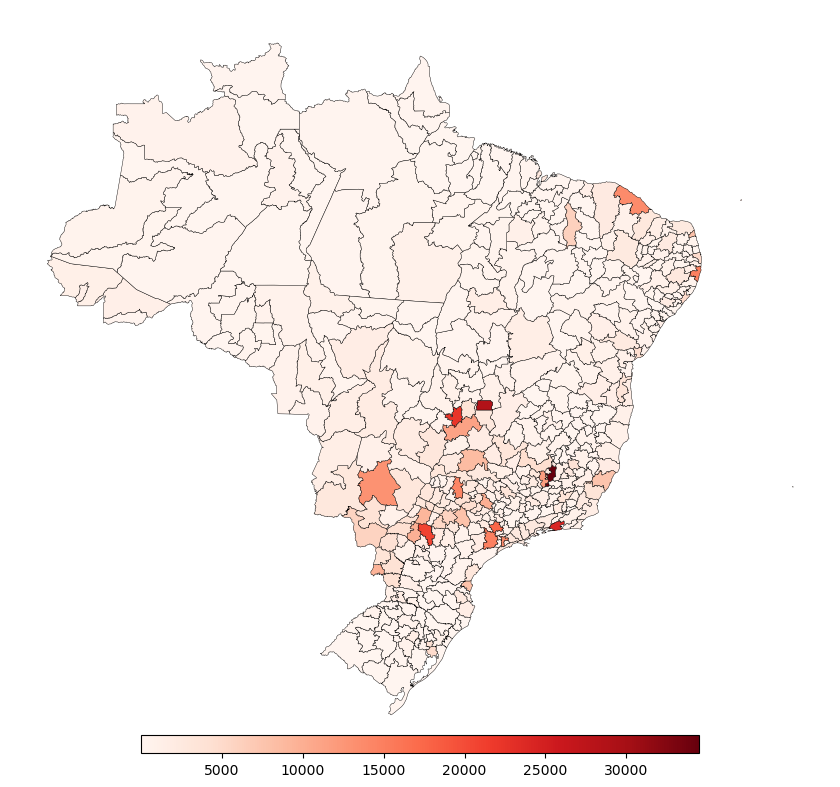

In [14]:
_,ax = plt.subplots(figsize = (12,12))

df_map_pred.plot(
    column='pred',
    cmap="Reds",      # typical diverging colormap
    #norm=norm,          # apply normalization
    linewidth=0.3,
    edgecolor="black",
    ax=ax,
    legend=True,
    legend_kwds={
        #"label": "",
        "orientation": "horizontal",  # or "vertical"
        "shrink": 0.6,                # make colorbar smaller
        "pad": 0.05,                  # space between map and colorbar
        "aspect": 30,                 # controls length/thickness
        "anchor": (0.5, 1.5)         # move colorbar (x, y)
    })

ax.axis('off')